# 50 — Self-supervised learning and pretext tasks

Supervised learning obtains its training signal from human-provided class labels. **Self-supervised learning** instead constructs targets from the data itself. The model solves a **pretext task** during pretraining, and we then evaluate whether its encoder learned features useful for a separate **downstream task**.

In this notebook we will:

- create rotation labels without using CIFAR-10 class labels;
- pretrain a small CNN to predict rotations of $0^\circ$, $90^\circ$, $180^\circ$, or $270^\circ$;
- freeze the encoder and train a linear classifier on a small labeled subset;
- compare the pretrained representation with a randomly initialized frozen encoder;
- inspect nearest neighbors in the learned feature space.

The purpose is not to obtain state-of-the-art CIFAR-10 accuracy. It is to understand how a label-free pretext task can teach an encoder reusable visual structure.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10

SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)
ROTATION_NAMES = ("0°", "90°", "180°", "270°")

print(f"Using {DEVICE}")

Using mps


## 1. Pretext tasks and downstream tasks

A self-supervised pipeline separates two roles:

1. **Pretraining:** an encoder $f_\theta$ learns from automatically generated targets. Here, rotating an image creates its own target: the number of quarter turns.
2. **Downstream evaluation:** the pretext head is discarded. A new classifier uses the encoder's features to predict CIFAR-10 classes.

The hope is that rotation prediction requires the encoder to recognize useful shapes and object parts. However, success is not guaranteed: a model may exploit shortcuts such as border artifacts, and features useful for rotation need not be ideal for object recognition.

### Exercise 1 — Identify the supervision

Answer briefly before continuing:

1. Which labels are generated automatically during pretraining?
2. Which labels require human annotation and are used only downstream?
3. Why is rotation prediction called *self-supervised* rather than unsupervised in the strict sense?

**Your answers:**

1. rotation angle labels
2. image object class
3. cause there is a target label but it comes from data itself

## 2. Create disjoint CIFAR-10 subsets

We use three different subsets:

- `pretrain_images`: images used **without CIFAR-10 labels** for rotation pretraining;
- `probe_images` and `probe_labels`: a small labeled set used to train a linear classifier;
- `evaluation_images` and `evaluation_labels`: held-out examples used only for evaluation.

Keeping the pretraining and probe subsets disjoint makes the roles easier to see. In large self-supervised systems, pretraining normally uses far more unlabeled data.

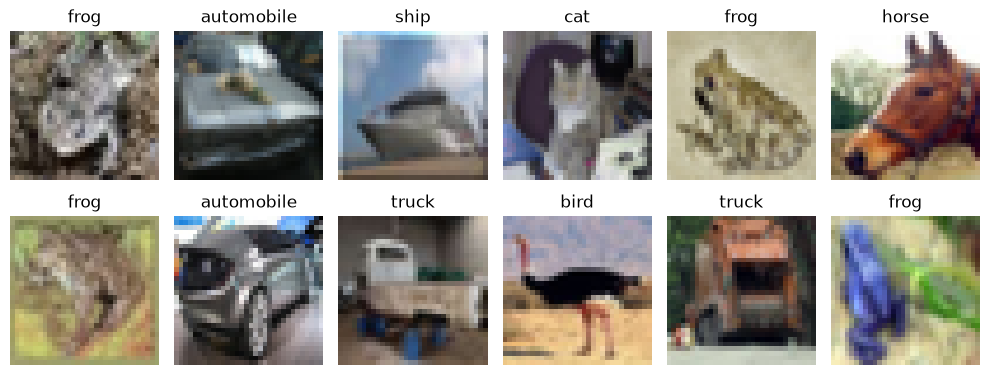

In [4]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)

# torchvision stores CIFAR-10 images as (N, H, W, C) uint8 arrays.
all_train_images = torch.from_numpy(train_dataset.data).permute(0, 3, 1, 2).float() / 255.0
all_train_labels = torch.tensor(train_dataset.targets)
all_test_images = torch.from_numpy(test_dataset.data).permute(0, 3, 1, 2).float() / 255.0
all_test_labels = torch.tensor(test_dataset.targets)

generator = torch.Generator().manual_seed(SEED)
train_order = torch.randperm(len(all_train_images), generator=generator)
test_order = torch.randperm(len(all_test_images), generator=generator)

pretrain_indices = train_order[:5000]
probe_indices = train_order[5000:6000]
evaluation_indices = test_order[:2000]

# Deliberately do not create pretrain_labels: the pretext task must not use them.
pretrain_images = all_train_images[pretrain_indices]
probe_images = all_train_images[probe_indices]
probe_labels = all_train_labels[probe_indices]
evaluation_images = all_test_images[evaluation_indices]
evaluation_labels = all_test_labels[evaluation_indices]

assert pretrain_images.shape == (5000, 3, 32, 32)
assert probe_images.shape == (1000, 3, 32, 32)
assert evaluation_images.shape == (2000, 3, 32, 32)

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for axis, image, label in zip(axes.flat, probe_images[:12], probe_labels[:12]):
    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(CLASS_NAMES[int(label)])
    axis.axis("off")
plt.tight_layout()
plt.show()

## 3. Generate the rotation pretext task

For every image in a minibatch, sample a rotation class $r \in \{0,1,2,3\}$. The transformed input is

$$
\tilde{x} = \mathrm{rotate}(x, 90^\circ r),
$$

and $r$ is the target. `torch.rot90` rotates the last two axes and avoids interpolation because every angle is a multiple of $90^\circ$.

### Exercise 2 — Create rotated images and their targets

Complete `make_rotation_batch`. Each image must receive an independently sampled rotation. A simple implementation can loop over the four rotation classes and transform all images assigned to each class.

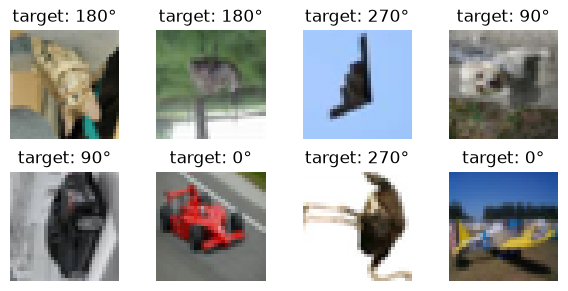

In [19]:
def make_rotation_batch(images, generator=None):
    """Return rotated copies of NCHW images and integer rotation targets."""
    if images.ndim != 4:
        raise ValueError("images must have shape (N, C, H, W)")

    # sample one integer in [0, 4) for every image.
    rotation_targets = torch.randint(
        4,
        size=(images.shape[0],),
        generator=generator,
    )
    # clone the images and rotate each target group with torch.rot90.
    rotated_images = images.clone()

    for index, target in enumerate(rotation_targets):
        rotated_images[index] = torch.rot90(
            images[index],
            k=int(target),
            dims=(-2, -1),
        )

    return rotated_images, rotation_targets


sample_images = pretrain_images[:8]
sample_generator = torch.Generator().manual_seed(4)
rotated_images, rotation_targets = make_rotation_batch(
    sample_images, generator=sample_generator
)

assert rotated_images.shape == sample_images.shape
assert rotation_targets.shape == (8,)
assert rotation_targets.dtype == torch.long
for index, target in enumerate(rotation_targets):
    expected = torch.rot90(sample_images[index], int(target), dims=(-2, -1))
    assert torch.equal(rotated_images[index], expected)

fig, axes = plt.subplots(2, 4, figsize=(6, 3))
for axis, image, target in zip(axes.flat, rotated_images, rotation_targets):
    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(f"target: {ROTATION_NAMES[int(target)]}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## 4. Separate the encoder from the pretext head

The encoder maps an image to a feature vector:

$$
h = f_\theta(x), \qquad h \in \mathbb{R}^{64}.
$$

The rotation head converts that feature vector into four logits. This separation is essential: after pretraining, we keep the encoder but discard the task-specific rotation head.

### Exercise 3 — Connect the encoder and rotation head

Complete both `forward` methods and verify the intermediate shapes.

In [21]:
class SmallEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, images):
        # apply self.features and flatten all dimensions after the batch axis.
        # (N, 3, 32, 32) -> Conv2d + MaxPool2d -> (N, 64, 8, 8) -> AdaptiveAvgPool2d(1) -> (N, 64, 1, 1)
        features = self.features(images)
        # (N, 64, 1, 1) -> (N, 64)
        return features.flatten(1)


class RotationPredictionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SmallEncoder()
        self.rotation_head = nn.Linear(64, 4)

    def forward(self, images):
        # encode the images and pass their features to the rotation head.
        return self.rotation_head(
            self.encoder(images)
        )


rotation_model = RotationPredictionModel()
sample_features = rotation_model.encoder(rotated_images)
sample_logits = rotation_model(rotated_images)

assert sample_features.shape == (8, 64)
assert sample_logits.shape == (8, 4)

## 5. Pretrain without CIFAR-10 labels

The loop below receives only images. `make_rotation_batch` creates both its transformed inputs and targets at runtime. The original class labels never enter the optimizer.

Rotation accuracy measures performance on the **pretext task**. It tells us whether the model learned to detect orientation, but only downstream evaluation tells us whether the representation transfers to object recognition.

In [22]:
def pretrain_rotation_model(
    model,
    images,
    epochs=6,
    batch_size=128,
    learning_rate=2e-3,
):
    loader = DataLoader(
        TensorDataset(images),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"loss": [], "accuracy": []}
    model.to(DEVICE)

    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        correct = 0
        example_count = 0

        for (image_batch,) in loader:
            rotated_batch, targets = make_rotation_batch(image_batch)
            rotated_batch = rotated_batch.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(rotated_batch)
            loss = nn.functional.cross_entropy(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * len(targets)
            correct += int((logits.argmax(dim=1) == targets).sum())
            example_count += len(targets)

        history["loss"].append(loss_sum / example_count)
        history["accuracy"].append(correct / example_count)
        print(
            f"epoch {epoch + 1:2d}: "
            f"loss={history['loss'][-1]:.3f}, "
            f"rotation accuracy={history['accuracy'][-1]:.3f}"
        )

    return history


rotation_history = pretrain_rotation_model(rotation_model, pretrain_images)

epoch  1: loss=1.387, rotation accuracy=0.247
epoch  2: loss=1.387, rotation accuracy=0.251
epoch  3: loss=1.384, rotation accuracy=0.276
epoch  4: loss=1.365, rotation accuracy=0.319
epoch  5: loss=1.333, rotation accuracy=0.347
epoch  6: loss=1.293, rotation accuracy=0.378


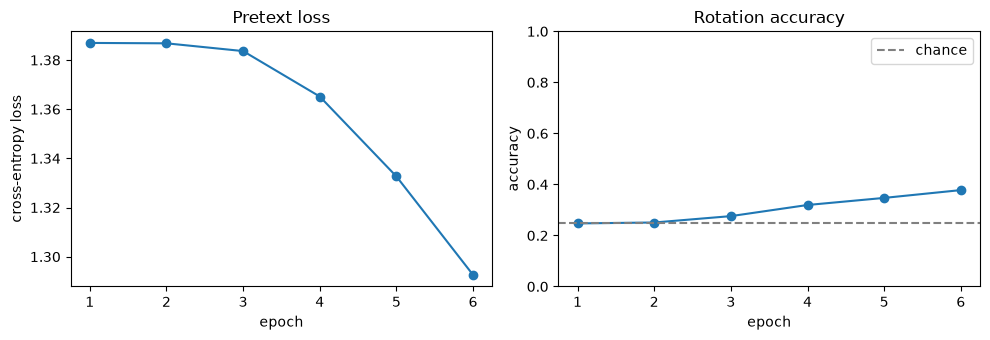

In [23]:
epochs = np.arange(1, len(rotation_history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(epochs, rotation_history["loss"], marker="o")
axes[0].set(xlabel="epoch", ylabel="cross-entropy loss", title="Pretext loss")
axes[1].plot(epochs, rotation_history["accuracy"], marker="o")
axes[1].axhline(0.25, color="gray", linestyle="--", label="chance")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="Rotation accuracy", ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

### Exercise 4 — Interpret pretext performance

1. Did the model exceed the chance accuracy of $1/4$?
2. Does high rotation accuracy prove that the encoder recognizes CIFAR-10 objects? Why or why not?
3. Name one visual shortcut that might help rotation prediction without providing semantic understanding.

**Your answers:**

1. Yes. Accuracy first exceeds the 25% chance level in epoch 3 and reaches 37.8% after six epochs.
2. No. High rotation accuracy only shows that the encoder contains information useful for predicting orientation. Whether it recognizes useful object structure must be tested on a downstream task, such as the frozen linear probe.
3. The model could learn that sky-like pixels usually belong near the top and ground-like pixels near the bottom, without learning the identity of the main object.

## 6. Frozen linear evaluation

A common representation test is the **linear probe**:

1. freeze the encoder so its parameters cannot change;
2. extract one feature vector per image;
3. train only a linear classifier on labeled data.

Because the probe cannot reshape the representation with a deep nonlinear network, its accuracy indicates how accessible the class information already is in the frozen features.

We compare two encoders with the same architecture:

- a randomly initialized encoder;
- the encoder learned by rotation prediction.

Both probes see exactly the same 1,000 labeled images.

### Exercise 5 — Freeze an encoder

Set every parameter's `requires_grad` flag to `False`, switch the encoder to evaluation mode, and return it.

In [27]:
def freeze_encoder(encoder):
    # disable gradient tracking for every parameter.
    for param in encoder.parameters():
        param.requires_grad = False
    # switch the module to evaluation mode.
    return encoder.eval()


pretrained_encoder = freeze_encoder(rotation_model.encoder)
assert not pretrained_encoder.training
assert all(not parameter.requires_grad for parameter in pretrained_encoder.parameters())

In [28]:
@torch.no_grad()
def extract_features(encoder, images, batch_size=256):
    encoder.eval()
    feature_batches = []
    for start in range(0, len(images), batch_size):
        batch = images[start:start + batch_size].to(DEVICE)
        feature_batches.append(encoder(batch).cpu())
    return torch.cat(feature_batches)


def train_linear_probe(
    train_features,
    train_labels,
    evaluation_features,
    evaluation_labels,
    epochs=40,
    learning_rate=5e-2,
):
    head = nn.Linear(train_features.shape[1], len(CLASS_NAMES)).to(DEVICE)
    optimizer = torch.optim.Adam(head.parameters(), lr=learning_rate)
    loader = DataLoader(
        TensorDataset(train_features, train_labels),
        batch_size=128,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    history = {"loss": [], "train_accuracy": [], "evaluation_accuracy": []}

    for _ in range(epochs):
        head.train()
        for feature_batch, label_batch in loader:
            feature_batch = feature_batch.to(DEVICE)
            label_batch = label_batch.to(DEVICE)
            loss = nn.functional.cross_entropy(head(feature_batch), label_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        head.eval()
        with torch.no_grad():
            train_logits = head(train_features.to(DEVICE))
            evaluation_logits = head(evaluation_features.to(DEVICE))
            history["loss"].append(float(loss))
            history["train_accuracy"].append(
                float((train_logits.argmax(1).cpu() == train_labels).float().mean())
            )
            history["evaluation_accuracy"].append(
                float(
                    (evaluation_logits.argmax(1).cpu() == evaluation_labels)
                    .float()
                    .mean()
                )
            )

    return head.cpu(), history


# Create this baseline only after pretraining so it retains random weights.
torch.manual_seed(SEED + 1)
random_encoder = freeze_encoder(SmallEncoder().to(DEVICE))

encoders = {
    "random frozen encoder": random_encoder,
    "rotation-pretrained encoder": pretrained_encoder,
}
probe_results = {}

for name, encoder in encoders.items():
    train_features = extract_features(encoder, probe_images)
    test_features = extract_features(encoder, evaluation_images)
    head, history = train_linear_probe(
        train_features,
        probe_labels,
        test_features,
        evaluation_labels,
    )
    probe_results[name] = {
        "head": head,
        "history": history,
        "train_features": train_features,
        "test_features": test_features,
    }
    print(
        f"{name:28s} | "
        f"train={history['train_accuracy'][-1]:.3f} | "
        f"evaluation={history['evaluation_accuracy'][-1]:.3f}"
    )

random frozen encoder        | train=0.243 | evaluation=0.242
rotation-pretrained encoder  | train=0.318 | evaluation=0.289


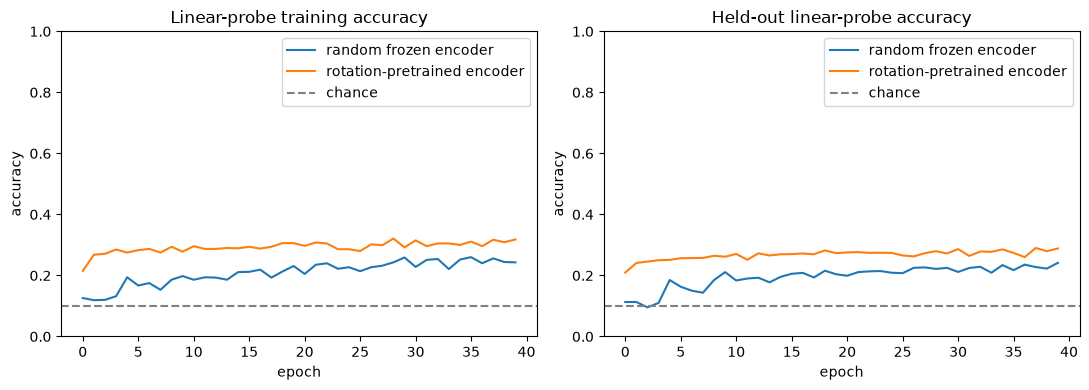

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, result in probe_results.items():
    history = result["history"]
    axes[0].plot(history["train_accuracy"], label=name)
    axes[1].plot(history["evaluation_accuracy"], label=name)

axes[0].set(title="Linear-probe training accuracy", xlabel="epoch", ylabel="accuracy")
axes[1].set(title="Held-out linear-probe accuracy", xlabel="epoch", ylabel="accuracy")
for axis in axes:
    axis.set_ylim(0, 1)
    axis.axhline(0.10, color="gray", linestyle="--", label="chance")
    axis.legend()
plt.tight_layout()
plt.show()

### Exercise 6 — Interpret the linear probe

1. Which frozen encoder gives better held-out accuracy?
2. Why is the random encoder a more informative baseline than the 10% class-chance line alone?
3. If pretraining does not help in this short experiment, does that disprove self-supervised learning? What experimental limitations matter?
4. Why must the encoder remain frozen for this particular comparison?

**Your answers:**

1. rotation-pretrained encoder performs better. 28.9% versus 24.2%.
2. to understand if there is useful info in pre-train encoder compare to random one. The random baseline measures what the architecture and random features provide without pretraining, isolating the value added by rotation pretraining.
3. No. The experiment uses limited data, few epochs, a small model, one seed, and little hyperparameter tuning.
4. Freezing prevents CIFAR-10 labels from changing the encoder, so the probe evaluates the representation learned during pretraining.

## 7. Inspect nearest neighbors in feature space

Classification accuracy is one summary of a representation. We can also inspect whether nearby feature vectors correspond to visually or semantically related images.

We L2-normalize the features, so their dot product is cosine similarity:

$$
\hat{h}_i = \frac{h_i}{\lVert h_i \rVert_2},
\qquad
\mathrm{similarity}(i,j) = \hat{h}_i^T \hat{h}_j.
$$

The query itself has the largest similarity, so we exclude it before selecting neighbors. Labels below are displayed only to interpret the result; they do not affect neighbor selection.

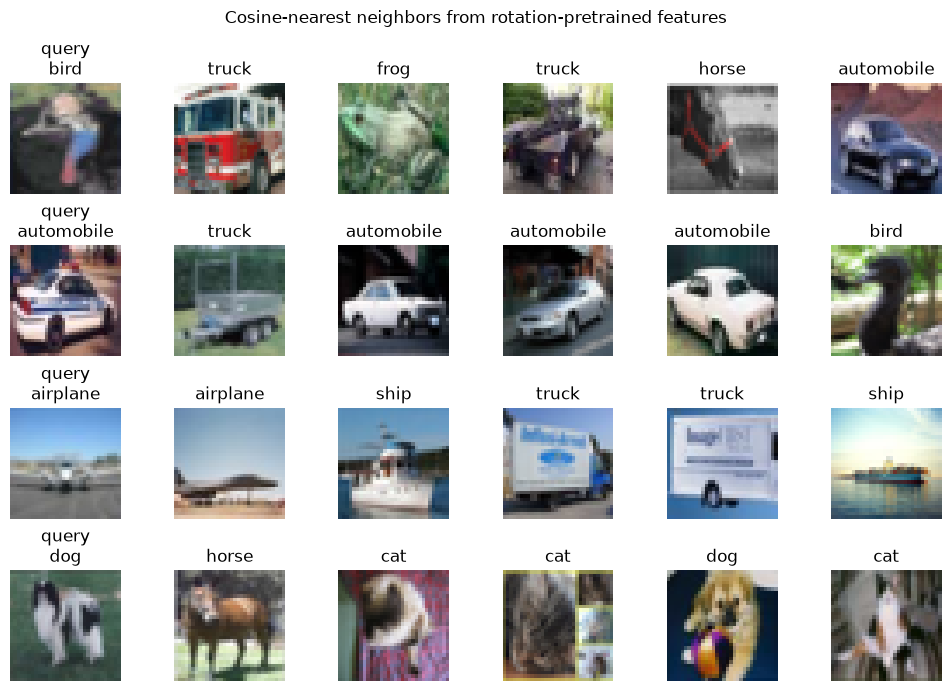

In [30]:
def nearest_neighbor_indices(features, query_index, number_of_neighbors=5):
    normalized = nn.functional.normalize(features, dim=1)
    similarities = normalized @ normalized[query_index]
    similarities[query_index] = -torch.inf
    return similarities.topk(number_of_neighbors).indices


features = probe_results["rotation-pretrained encoder"]["test_features"]
query_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(len(query_indices), 6, figsize=(10, 7))

for row, query_index in enumerate(query_indices):
    neighbors = nearest_neighbor_indices(features, query_index)
    displayed_indices = [query_index] + neighbors.tolist()
    for column, index in enumerate(displayed_indices):
        axes[row, column].imshow(evaluation_images[index].permute(1, 2, 0))
        title_prefix = "query\n" if column == 0 else ""
        axes[row, column].set_title(title_prefix + CLASS_NAMES[int(evaluation_labels[index])])
        axes[row, column].axis("off")

plt.suptitle("Cosine-nearest neighbors from rotation-pretrained features")
plt.tight_layout()
plt.show()

### Exercise 7 — What do the neighbors preserve?

Look for similarities in object class, color, texture, background, and orientation.

1. Do most neighbors share the query's class?
2. If two images are close because of background color rather than object identity, is that necessarily a bug in the code?
3. Why should this small visualization not replace quantitative evaluation?

**Your answers:**

1. Not consistently. Some classes, such as automobiles, group better, and broader groups such as animals or vehicles sometimes appear close.
2. No. Rotation pretraining can organize features using background, color, texture, shape, or orientation rather than exact object identity.
3. It shows only a few subjectively interpreted examples; quantitative evaluation covers the full dataset and provides a reproducible measurement.

## 8. Other sources of self-supervision

Rotation is only one way to derive targets from the data:

- **inpainting:** predict a missing image region from its surroundings;
- **colorization:** predict color from grayscale structure;
- **jigsaw puzzles:** predict the correct arrangement of shuffled patches;
- **masked image modeling:** reconstruct masked patches or their representations;
- **temporal correspondence:** use nearby video frames as related views;
- **multisensory supervision:** predict or align naturally synchronized signals such as video and audio, or RGB and depth.

Each task introduces an inductive bias. For example, colorization encourages semantic and contextual features, while audio-video alignment encourages features related to visible sound sources. Later notebooks will focus on contrastive learning and masked image modeling, which generally provide stronger and more scalable objectives than handcrafted pretext classifications such as rotation.

## Reflection

1. What is the difference between a pretext task and a downstream task?
2. Why can CIFAR-10 class labels be stored in the same dataset without being used during self-supervised pretraining?
3. Why do we discard the rotation head but retain the encoder?
4. What does a frozen linear probe measure?
5. Why compare against a frozen random encoder using the same architecture?
6. Why does strong pretext-task accuracy not guarantee a strong representation?
7. What kinds of shortcuts might rotation prediction exploit?
8. How does multisensory supervision obtain targets without manual class labels?
9. What is one limitation of this small CIFAR-10 experiment?

### Answers

1. 
2. 
3. 
4. 
5. 
6. 
7. 
8. 
9. 